# Download Data

In [1]:
import pandas as pd

df = pd.read_parquet('../data/Player-Games_Injuries_Travel_Bio.parquet')
df = df.drop(columns=['days_to_next_injury', 'injury_within_7d',
                      'injury_within_30d','Name', 'coachId'])
df.head()

,personId,gameId,gameDateTimeEst_player,playerteamName,gameType_player,win_player,home_player,numMinutes_player,points_player,assists_player,...,direction_ew,tz_shift_hrs,rest_days,flight_minutes,height,weight,birthdate,experience,bmi,age
0,255.0,21000521,2011-01-05 22:30:00,Suns,Regular Season,0.0,1.0,34.0,10.0,2.0,...,East,1.0,2.0,69.3,80.0,225.0,1972-10-05,18,24.714844,38.250513
1,255.0,21000533,2011-01-07 22:30:00,Suns,Regular Season,0.0,1.0,29.0,10.0,2.0,...,N/A,0.0,1.0,0.0,80.0,225.0,1972-10-05,18,24.714844,38.255989
2,255.0,21000584,2011-01-14 22:30:00,Suns,Regular Season,1.0,1.0,36.0,21.0,3.0,...,N/A,0.0,1.0,0.0,80.0,225.0,1972-10-05,18,24.714844,38.275154
3,255.0,21000598,2011-01-17 13:00:00,Suns,Regular Season,1.0,0.0,37.0,25.0,2.0,...,East,2.0,2.0,234.0,80.0,225.0,1972-10-05,18,24.714844,38.283368
4,255.0,21000613,2011-01-19 19:00:00,Suns,Regular Season,1.0,0.0,40.0,27.0,2.0,...,West,0.0,1.0,44.1,80.0,225.0,1972-10-05,18,24.714844,38.288843


In [2]:
seasons = sorted(df['season_x'].unique())

test_season = seasons[-1]
val_season = seasons[-2]
train_seasons = seasons[:-2]

test_df = df[df['season_x'] == test_season]
val_df = df[df['season_x'] == val_season]
train_df = df[df['season_x'].isin(train_seasons)]

In [3]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
import numpy as np

def univariate_auc(feature, X, y, groups, n_splits=5):
  X_feat = X[[feature]].values
  gkf = GroupKFold(n_splits=n_splits)
  aucs = []

  for train_idx, test_idx in gkf.split(X_feat, y, groups):
    X_train, X_test = X_feat[train_idx], X_feat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    imputer = SimpleImputer(strategy='mean')
    X_train = imputer.fit_transform(X_train)
    X_test = imputer.transform(X_test)

    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y_test, y_pred))

  return np.mean(aucs) if len(aucs) > 0 else np.nan

In [4]:
target = 'injury_within_14d'
group_col = 'personId'

X = train_df.drop(columns=[target])
y = train_df[target].values
groups = train_df[group_col].values

results = []

# Not using stats from the same game due to potential leakage
drop_cols = ['season_x', 'numMinutes_player', 'points_player',
             'assists_player', 'blocks_player', 'steals_player',
             'fieldGoalsAttempted_player', 'fieldGoalsMade_player',
             'fieldGoalsPercentage_player', 'threePointersAttempted_player',
             'threePointersMade_player', 'threePointersPercentage_player',
             'freeThrowsAttempted_player', 'freeThrowsMade_player',
             'freeThrowsPercentage_player', 'reboundsDefense_player',
             'reboundsOffensive_player', 'reboundsTotal_player',
             'foulsPersonal_player', 'turnovers_player', 'plusMinusPoints_player',
             'playerteamId_player', 'comment', 'points_per36', 'assists_per36',
             'blocks_per36', 'steals_per36', 'fieldGoalsAttempted_per36',
             'fieldGoalsMade_per36', 'threePointersAttempted_per36',
             'threePointersMade_per36', 'freeThrowsAttempted_per36',
             'freeThrowsMade_per36', 'reboundsDefensive_per36',
             'reboundsOffensive_per36', 'reboundsTotal_per36',
             'foulsPersonal_per36', 'turnovers_per36', 'plusMinusPoints_per36',
             'playerteamId_team', 'points_team', 'assists_team',
             'blocks_team', 'steals_team', 'fieldGoalsAttempted_team',
             'fieldGoalsMade_team', 'fieldGoalsPercentage_team',
             'threePointersAttempted_team', 'threePointersMade_team',
             'threePointersPercentage_team', 'freeThrowsAttempted_team',
             'freeThrowsMade_team', 'freeThrowsPercentage_team',
             'reboundsDefensive_team', 'reboundsOffensive_team',
             'reboundsTotal_team', 'foulsPersonal_team',
             'turnovers_team', 'plusMinusPoints_team', 'numMinutes_team',
             'benchPoints', 'pointsFastBreak', 'pointsFromTurnovers',
             'pointsInThePaint', 'pointsSecondChance', 'reboundsTeam',
             'turnoversTeam', 'pointDifferential', 'pointsPercent',
             'assistsPercent', 'stealsPercent', 'fieldGoalsAttemptedPercent',
             'fieldGoalsMadePercent', 'freeThrowsAttemptedPercent',
             'freeThrowsMadePercent', 'reboundsDefensivePercent',
             'reboundsOffensivePercent', 'reboundsTotalPercent',
             'foulsPersonalPercent', 'turnoversPercent', 'fgRelativePercent',
             '3pRelativePercent', 'ftRelativePercent', '3PA_rate',
             'trueShooting', 'eFG', 'FTA_rate', 'USG', 'personId', 'gameId', 'reboundsDefensive_player']

features = X.select_dtypes(include=[np.number]).columns
features = [f for f in features if f not in drop_cols]

for f in features:
  auc = univariate_auc(f, X, y, groups)
  results.append((f, auc))
  print(f'{f}: {auc}')

results.sort(key=lambda x: x[1], reverse=True)
results_df = pd.DataFrame(results, columns=['feature', 'auc'])
results_df.head()

win_player: 0.5113716509331458
home_player: 0.5006088702470142
winPercent_team: 0.5447146285877099
positionless_index: 0.5213946531880909
rolling_3g_minutes: 0.59630565735867
rolling_3g_points: 0.6143202833052237
rolling_3g_assists: 0.5876513537196837
rolling_3g_rebounds: 0.5660372085405193
rolling_3g_steals: 0.5481229539161004
rolling_3g_blocks: 0.5382476531988427
rolling_3g_turnovers: 0.566549159140554
rolling_3g_field_goals_made: 0.6088115418386109
rolling_3g_field_goals_attempted: 0.6107620986960225
rolling_3g_three_pointers_made: 0.5882393792625827
rolling_3g_three_pointers_attempted: 0.6018967816376313
rolling_3g_three_point_percent: 0.5559799629357721
rolling_3g_points_per36: 0.5951193884238833
rolling_3g_assists_per36: 0.5648718384523802
rolling_3g_blocks_per36: 0.47063223637144463
rolling_3g_steals_per36: 0.4949795792389698
rolling_3g_3p_relative_percent: 0.5506965663010721
rolling_3g_ft_relative_percent: 0.5584130554324394
rolling_3g_USG: 0.5718449657805537
rolling_7g_minutes

,feature,auc
0,rolling_7g_points,0.622145
1,rolling_7g_field_goals_made,0.617511
2,rolling_7g_field_goals_attempted,0.615589
3,rolling_3g_points,0.614320
4,rolling_3g_field_goals_attempted,0.610762


In [5]:
threshold = 0.52

selected_features = results_df[
    results_df['auc'] >= threshold
]

print(f'Total Features: {len(features)}')
print(f'Selected Features: {len(selected_features)}')


Total Features: 53
Selected Features: 37


In [6]:
from utils import prune_redundant_features

kept_features, drop_cols = prune_redundant_features(X[selected_features['feature']])
print(f'Kept Features: {len(kept_features)}')
print(f'Dropped Features: {len(drop_cols)}')

Kept Features: 36
Dropped Features: 1


In [7]:
print(kept_features)

{'rolling_3g_points', 'rolling_3g_3p_relative_percent', 'rolling_7g_field_goals_made', 'rolling_3g_assists', 'rolling_7g_ft_relative_percent', 'rolling_7g_field_goals_attempted', 'rolling_7g_blocks', 'rolling_7g_turnovers', 'winPercent_team', 'rolling_3g_three_point_percent', 'rolling_3g_turnovers', 'rolling_7g_three_point_percent', 'rolling_7g_assists_per36', 'rolling_3g_steals', 'rolling_3g_field_goals_made', 'rolling_3g_three_pointers_made', 'rolling_3g_rebounds', 'rolling_3g_points_per36', 'rolling_3g_blocks', 'rolling_7g_points_per36', 'rolling_7g_steals', 'rolling_3g_USG', 'rolling_3g_ft_relative_percent', 'rolling_3g_field_goals_attempted', 'rolling_7g_points', 'rolling_3g_three_pointers_attempted', 'rolling_7g_assists', 'rolling_7g_three_pointers_attempted', 'positionless_index', 'rolling_7g_three_pointers_made', 'rolling_7g_minutes', 'rolling_7g_3p_relative_percent', 'rolling_7g_rebounds', 'rolling_3g_assists_per36', 'rolling_7g_USG', 'games_last_14d'}


# Model Selection
Using various non-tuned models

In [8]:
%pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [9]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import time

X_sel = df[list(kept_features) + ['season_x']].copy()
y_sel = df[target].values

pos = np.sum(y_sel == 1)
neg = np.sum(y_sel == 0)
scale_pos_weight = min(10, neg / pos)

models = {
    "logreg_l2": LogisticRegression(max_iter=500, penalty="l2", solver="lbfgs", n_jobs=-1,
                                    class_weight = 'balanced'),

    "logreg_l1": LogisticRegression(max_iter=500, penalty="l1", solver="saga", n_jobs=-1,
                                    class_weight = 'balanced'),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        scale_pos_weight = scale_pos_weight
    ),

    "lightgbm": LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight = 'balanced'
    ),

    "catboost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        verbose=0,
        random_seed=42
    ),

    'mlp_nn': MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=200,
        random_state=42
    )
}

def evaluate_model_temporal(model, X, y):
  start = time.perf_counter()
  train_mask = X['season_x'].isin(train_seasons)
  val_mask = X['season_x'] == val_season
  X_train = X.loc[train_mask].drop(columns=['season_x'])
  X_val = X.loc[val_mask].drop(columns=['season_x'])
  y_train = y[train_mask]
  y_val = y[val_mask]

  imputer = SimpleImputer(strategy='median')

  X_train = imputer.fit_transform(X_train)
  X_val = imputer.transform(X_val)

  if isinstance(model, (MLPClassifier, LogisticRegression)):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
  model.fit(X_train, y_train)
  preds = model.predict_proba(X_val)[:, 1]
  auc = roc_auc_score(y_val, preds)
  return auc, time.perf_counter() - start

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
results = []

for name, model in models.items():
    print(f"Evaluating {name}...")
    auc, elapsed = evaluate_model_temporal(
        model, X_sel, y_sel
    )

    results.append({
        "model": name,
        "auc": auc,
    })

    print(f"{name}: AUC = {auc:.4f}. Took {elapsed:.3f} seconds.")

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
results_df

Evaluating logreg_l2...
logreg_l2: AUC = 0.5800. Took 26.115 seconds.
Evaluating logreg_l1...
logreg_l1: AUC = 0.5800. Took 15.030 seconds.
Evaluating random_forest...
random_forest: AUC = 0.5854. Took 445.118 seconds.
Evaluating xgboost...
xgboost: AUC = 0.5939. Took 25.215 seconds.
Evaluating lightgbm...
[LightGBM] [Info] Number of positive: 26673, number of negative: 260253
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.133044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5590
[LightGBM] [Info] Number of data points in the train set: 286926, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


lightgbm: AUC = 0.5966. Took 26.743 seconds.
Evaluating catboost...
catboost: AUC = 0.6008. Took 49.538 seconds.
Evaluating mlp_nn...
mlp_nn: AUC = 0.5660. Took 379.557 seconds.


,model,auc
5,catboost,0.600809
4,lightgbm,0.596594
3,xgboost,0.593921
2,random_forest,0.585374
0,logreg_l2,0.580044
1,logreg_l1,0.580039
6,mlp_nn,0.565965


CatBoost seems to perform the best.

In [ ]:
from sklearn.metrics import average_precision_score, precision_recall_curve

X_sel = df[list(kept_features) + ['season_x']].copy()
y_sel = df[target].values

train_mask = X_sel['season_x'].isin(train_seasons)
val_mask = X_sel['season_x'] == val_season
test_mask = X_sel['season_x'] == test_season

X_train = X_sel.loc[train_mask].drop(columns=['season_x'])
X_val = X_sel.loc[val_mask].drop(columns=['season_x'])
X_test = X_sel.loc[test_mask].drop(columns=['season_x'])

y_train = y_sel[train_mask]
y_val = y_sel[val_mask]
y_test = y_sel[test_mask]

X_full_train = pd.concat([X_train, X_val], axis=0)
y_full_train = np.concatenate([y_train, y_val])

imputer = SimpleImputer(strategy='median')
imputer.set_output(transform="pandas")
X_full_train = imputer.fit_transform(X_full_train)
X_test = imputer.transform(X_test)

model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=0,
        random_seed=42
    )

model.fit(X_full_train, y_full_train)
preds = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, preds)
auc

np.float64(0.6238587620912819)

In [ ]:
baseline = y_test.mean()
baseline

np.float64(0.19819505602301957)

In [ ]:
ap = average_precision_score(y_test, preds)
ap

np.float64(0.2716971350645433)

In [ ]:
probs = pd.DataFrame({
    "y": y_test,
    "p": preds
}).sort_values("p", ascending=False)

for pct in [1, 5, 10, 20]:
    n = int(len(probs) * pct / 100)
    precision = probs.head(n)["y"].mean()
    print(f"Top {pct}%: {precision:.3f}")

Top 1%: 0.341
Top 5%: 0.325
Top 10%: 0.313
Top 20%: 0.297


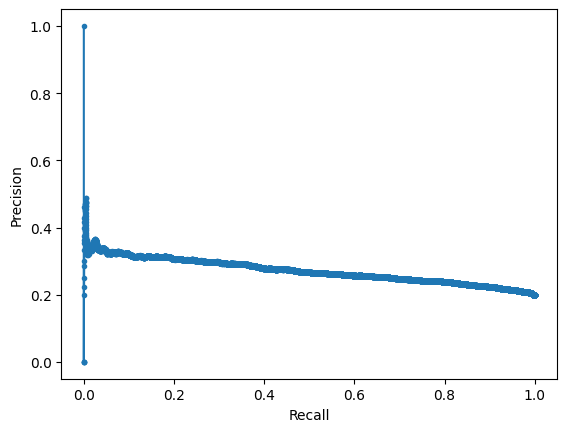

In [ ]:
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, preds)

plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

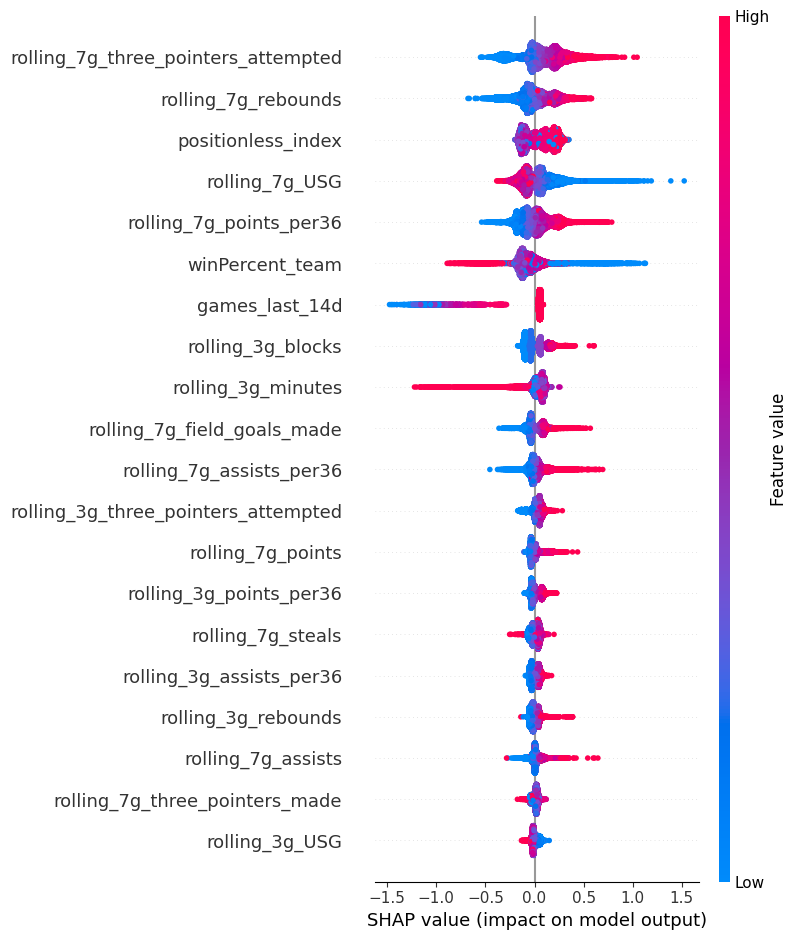

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)